In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel("Dataset/Delivery_prediction_Dataset_.xlsx")

In [19]:
df.head()

,delivery_id,delivery_partner,order_date,delivery_date,state,city,package_type,vehicle_type,delivery_mode,weather_condition,...,address_verified,payment_method,fuel_level,vehicle_breakdown,delivery_attempts,holiday,delivery_cost_ngn,failure_reason,delivery_status,delivery_failure
0,DLV000001,Jumia Logistics,2025-01-01,2025-01-02,Oyo,Ibadan,Electronics,Bike,Standard,Sunny,...,No,Cash on Delivery,High,Yes,3,Yes,39321,Flood,Failed,1
1,DLV000002,Jumia Logistics,2025-01-01,2025-01-02,FCT,Garki,Food,Bike,Standard,Sunny,...,Yes,Transfer,Medium,No,3,No,25196,NaN,Delivered,0
2,DLV000003,Jumia Logistics,2025-01-01,2025-01-02,Kano,Kano,Food,Bike,Standard,Harmattan,...,Yes,Transfer,Medium,No,3,No,40452,NaN,Delivered,0
3,DLV000004,Kobo360,2025-01-01,2025-01-02,Oyo,Ibadan,Food,Bike,Standard,Heavy Rain,...,No,Transfer,Medium,No,3,Yes,12402,Customer Not Home,Failed,1
4,DLV000005,Jumia Logistics,2025-01-01,2025-01-02,Kano,Kano,Documents,Bike,Standard,Harmattan,...,Yes,Transfer,High,Yes,1,No,9724,NaN,Delivered,0


In [20]:
def eda_summary(df):
    summary = pd.DataFrame({
        'dtype': df.dtypes,
        'non_null': df.count(),
        'null_count': df.isnull().sum(),
        'null_pct': (df.isnull().mean() * 100).round(2),
        'unique': df.nunique(),
        'unique_pct': (df.nunique() / len(df) * 100).round(2),
        'duplicated_count': df.duplicated().sum(), 
        'duplicated_pct': (df.duplicated().mean() * 100).round(2) 
    })
    num_stats = df.describe().T[['mean','std','min','max']]
    summary = summary.join(num_stats)
    
    return summary

In [39]:
eda_summary(df)

,dtype,non_null,null_count,null_pct,unique,unique_pct,duplicated_count,duplicated_pct,mean,std,min,max
delivery_id,str,10000,0,0.00,10000,100.00,0,0.0,NaN,NaN,NaN,NaN
delivery_partner,str,10000,0,0.00,4,0.04,0,0.0,NaN,NaN,NaN,NaN
order_date,str,10000,0,0.00,1,0.01,0,0.0,NaN,NaN,NaN,NaN
delivery_date,str,10000,0,0.00,1,0.01,0,0.0,NaN,NaN,NaN,NaN
state,str,10000,0,0.00,6,0.06,0,0.0,NaN,NaN,NaN,NaN
city,str,10000,0,0.00,10,0.10,0,0.0,NaN,NaN,NaN,NaN
package_type,str,10000,0,0.00,3,0.03,0,0.0,NaN,NaN,NaN,NaN
vehicle_type,str,10000,0,0.00,3,0.03,0,0.0,NaN,NaN,NaN,NaN
delivery_mode,str,10000,0,0.00,1,0.01,0,0.0,NaN,NaN,NaN,NaN
weather_condition,str,10000,0,0.00,4,0.04,0,0.0,NaN,NaN,NaN,NaN


Data Cleaning

In [40]:
# Categorical Data Entry Errors
for col in ['weather_condition', 'traffic_level', 'road_condition', 'delivery_partner']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- weather_condition ---
weather_condition
Rainy         2546
Heavy Rain    2520
Harmattan     2468
Sunny         2466
Name: count, dtype: int64

--- traffic_level ---
traffic_level
Heavy       3368
Low         3285
Moderate    3255
Hevy          92
Name: count, dtype: int64

--- road_condition ---
road_condition
Fair    3408
Good    3310
Bad     3282
Name: count, dtype: int64

--- delivery_partner ---
delivery_partner
GIG Logistics      2580
Kobo360            2514
Jumia Logistics    2484
Kwik               2422
Name: count, dtype: int64


In [41]:
# Categorical Data Entry Errors
df['traffic_level'] = df['traffic_level'].replace({'Hevy': 'Heavy'})

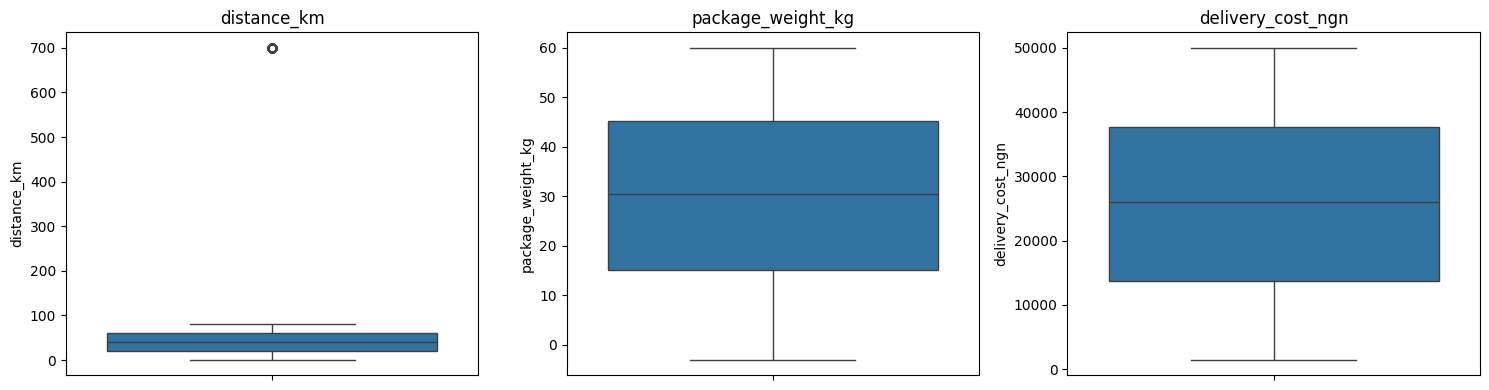

In [42]:
#Outlier Detection
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['distance_km', 'package_weight_kg', 'delivery_cost_ngn']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [43]:
#Constant value: distance_km = 700 found in multiple rows
cols_to_check = ['distance_km', 'expected_time_hours', 'actual_time_hours',
                  'delivery_cost_ngn', 'city', 'state', 'delivery_partner']
df[df['distance_km'] > 200][cols_to_check]

count_700 = (df['distance_km'] == 700).sum()
print(f"Affected rows: {count_700} ({count_700/len(df)*100:.2f}%)")
# package_weight_kg has negative values
count_negative = (df['package_weight_kg'] < 0).sum()
print(f"Affected rows: {count_negative} ({count_negative/len(df)*100:.2f}%)")

Affected rows: 106 (1.06%)
Affected rows: 36 (0.36%)


In [44]:
#Cleaning — Outlier Removal
df = df[df['distance_km'] != 700]
df = df[df['package_weight_kg'] >= 0]

In [45]:
#data leakage
leakage_cols = ['delivery_attempts', 'actual_time_hours', 'failure_reason',
                 'delivery_status', 'vehicle_breakdown', 'delivery_id']

df = df.drop(columns=leakage_cols)

C:\Users\USER\AppData\Local\Temp\ipykernel_7656\3800978856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_rate.values, y=failure_rate.index, ax=axes[i], palette="rocket")
C:\Users\USER\AppData\Local\Temp\ipykernel_7656\3800978856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_rate.values, y=failure_rate.index, ax=axes[i], palette="rocket")
C:\Users\USER\AppData\Local\Temp\ipykernel_7656\3800978856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_rate.values, y=failure_rate.index, ax=axes[i], palette

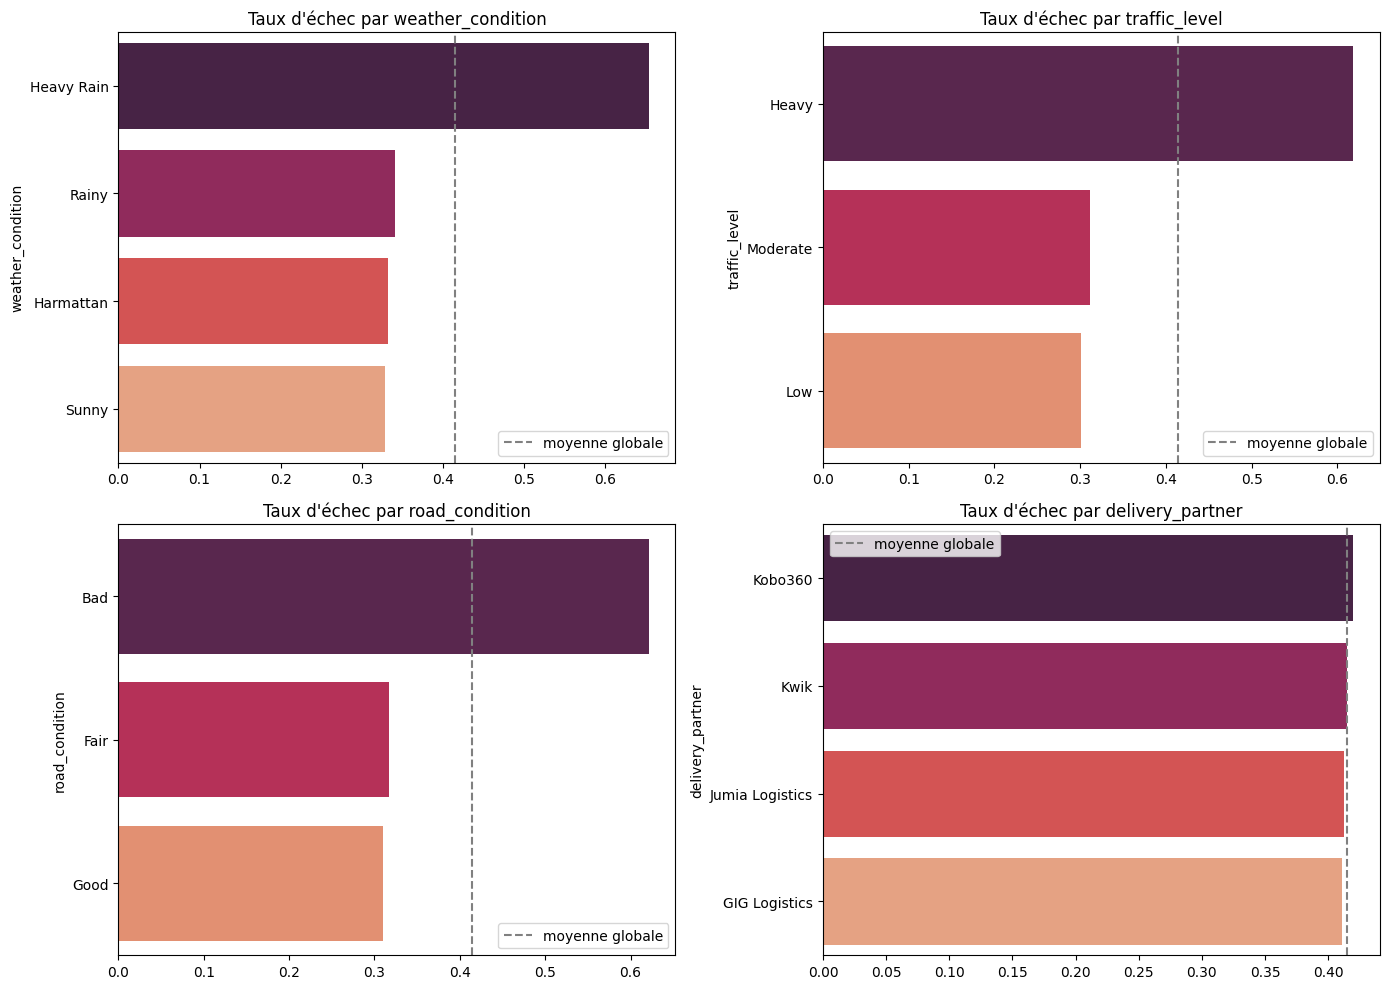

In [46]:
# EDA — Failure Rate by Categorical Feature
cat_cols = ['weather_condition', 'traffic_level', 'road_condition', 'delivery_partner']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    failure_rate = df.groupby(col)['delivery_failure'].mean().sort_values(ascending=False)
    sns.barplot(x=failure_rate.values, y=failure_rate.index, ax=axes[i], palette="rocket")
    axes[i].set_title(f"Taux d'échec par {col}")
    axes[i].axvline(df['delivery_failure'].mean(), color='gray', linestyle='--', label='moyenne globale')
    axes[i].legend()
plt.tight_layout()
plt.show()

In [ ]:
correlation matrix

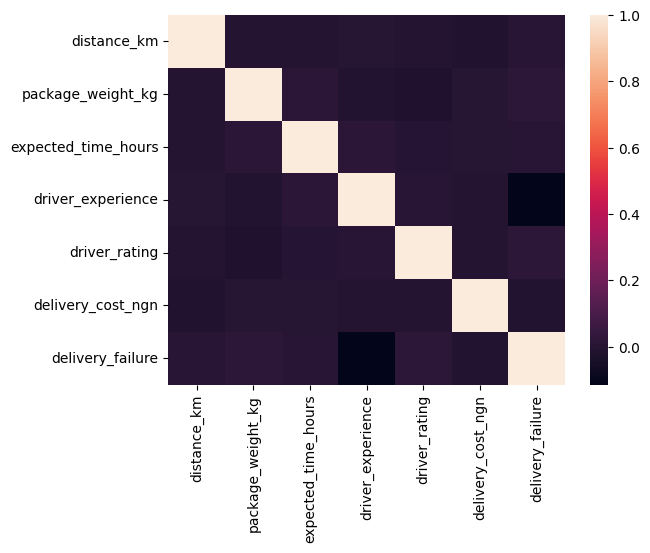

In [47]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='rocket', annot=False)
plt.show()

In [52]:
print("final Dataset:", df.shape)

final Dataset: (9858, 24)


In [54]:
df.head()

,delivery_partner,order_date,delivery_date,state,city,package_type,vehicle_type,delivery_mode,weather_condition,traffic_level,...,driver_id,driver_experience,driver_rating,customer_available,address_verified,payment_method,fuel_level,holiday,delivery_cost_ngn,delivery_failure
0,Jumia Logistics,2025-01-01,2025-01-02,Oyo,Ibadan,Electronics,Bike,Standard,Sunny,Heavy,...,DRV0424,12,3.9,Yes,No,Cash on Delivery,High,Yes,39321,1
1,Jumia Logistics,2025-01-01,2025-01-02,FCT,Garki,Food,Bike,Standard,Sunny,Low,...,DRV0349,13,3.8,Yes,Yes,Transfer,Medium,No,25196,0
2,Jumia Logistics,2025-01-01,2025-01-02,Kano,Kano,Food,Bike,Standard,Harmattan,Moderate,...,DRV0286,15,3.9,Yes,Yes,Transfer,Medium,No,40452,0
3,Kobo360,2025-01-01,2025-01-02,Oyo,Ibadan,Food,Bike,Standard,Heavy Rain,Low,...,DRV0379,2,3.1,No,No,Transfer,Medium,Yes,12402,1
4,Jumia Logistics,2025-01-01,2025-01-02,Kano,Kano,Documents,Bike,Standard,Harmattan,Moderate,...,DRV0075,13,3.5,Yes,Yes,Transfer,High,No,9724,0
